In [1]:
import numpy as np
import pandas as pd
import sklearn.metrics as skm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor as rfs
from sklearn.neural_network import MLPRegressor 
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression 
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

from scipy.stats import uniform as sp_randFloat
from scipy.stats import randint as sp_randInt

def mape(Y_actual,Y_Predicted):
    mape = np.mean(np.abs((Y_actual - Y_Predicted)/Y_actual))*100
    return mape

In [2]:
data = pd.read_csv('est_validiation.csv')

In [3]:
data

,Unnamed: 0,Yobs,Yest,prec,et_obs,et_est,year,month
0,0,154.050025,132.080217,126.42,154.050025,132.080217,2015,1
1,1,113.652797,104.533858,219.28,113.652797,104.533858,2015,2
2,2,110.835384,103.471126,219.52,110.835384,103.471126,2015,3
3,3,105.644868,95.391611,68.37,105.644868,95.391611,2015,4
4,4,72.644352,68.925077,57.67,72.644352,68.925077,2015,5
...,...,...,...,...,...,...,...,...
3943,3943,93.013654,84.761106,4.03,93.013654,84.761106,2021,8
3944,3944,143.413039,129.572808,32.04,143.413039,129.572808,2021,9
3945,3945,126.339973,113.524401,144.90,126.339973,113.524401,2021,10
3946,3946,92.194446,87.907068,321.45,92.194446,87.907068,2021,11


In [4]:
r2 = skm.r2_score(data['Yobs'],data['Yest'])
mse=skm.mean_squared_error(data['Yobs'],data['Yest'])
rmse = mse**0.5
mae = skm.mean_absolute_error(data['Yobs'],data['Yest'])
rrmse = rmse*100/np.mean(data['Yobs'])
rf_mape = mape(data['Yobs'],data['Yest'])

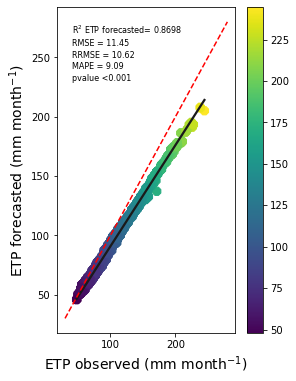

In [7]:
points = plt.scatter(y='Yest', x='Yobs',data=data,
                     c=data["Yobs"],marker="8", s=80, cmap="viridis")   
cbar = plt.colorbar(points, shrink=1)

sns.regplot(y='Yest', x='Yobs', data=data, scatter=False, color=".1")

x=[30,280]
y=x


plt.plot(x,y, 'r--',data=None)

pvalue = 0.001
plt.text(40, 270, 'R$\mathregular{^{2}}$ ETP forecasted= %0.4f' % r2,family='Segoe UI Bold',fontsize=8, color= 'black')
plt.text(40,260, 'RMSE = %0.2f'% rmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,250, 'RRMSE = %0.2f'% rrmse,family='Segoe UI Bold',fontsize=8)
plt.text(40,240, 'MAPE = %0.2f'% rf_mape,family='Segoe UI Bold',fontsize=8)
plt.text(40, 230,'pvalue <%0.3f' % pvalue,family='Segoe UI Bold',fontsize=8)
plt.xlabel('ETP observed (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.ylabel('ETP forecasted (mm month$\mathregular{^{-1}}$)',fontsize=14, family='Segoe UI Bold')
plt.rcParams['figure.figsize'] = (4,6)

plt.savefig('rf_validation.png', transparent = False,bbox_inches='tight', dpi=1000)